<a href="https://colab.research.google.com/github/unnati-negi/GENAI/blob/main/GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
latent_dim = 100
batch_size = 64
lr = 0.0002
epochs = 15

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5))
])

In [ ]:
dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

In [ ]:
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
class Generator(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(latent_dim,128),
        nn.ReLU(True),
        nn.Linear(128,256),
        nn.BatchNorm1d(256),
        nn.ReLU(True),
        nn.Linear(256,512),
        nn.BatchNorm1d(512),
        nn.ReLU(True),
        nn.Linear(512,784),
        nn.Tanh()
    )
  def forward(self,z):
    return self.model(z)

In [ ]:
class Discriminator(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(784,512),
        nn.LeakyReLU(0.2,inplace=True),
        nn.Linear(512,256),
        nn.LeakyReLU(0.2,inplace=True),
        nn.Linear(256,1),
        nn.Sigmoid()
    )
  def forward(self,z):
    return self.model(z)

In [ ]:
G= Generator().to(device)
D= Discriminator().to(device)

In [ ]:
criterion= nn.BCELoss()

In [ ]:
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

In [ ]:
fixed_noise = torch.randn(16, latent_dim).to(device)


Epoch [1/15]  D_loss: 1.2098  G_loss: 0.8785


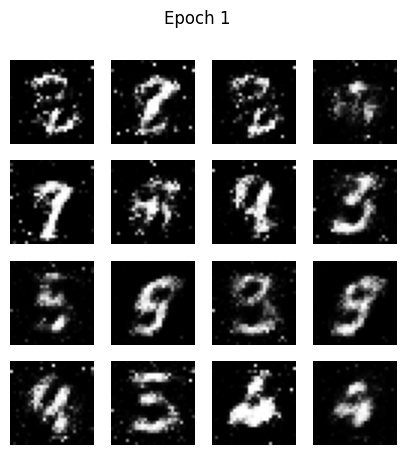


Epoch [2/15]  D_loss: 1.0848  G_loss: 2.0877


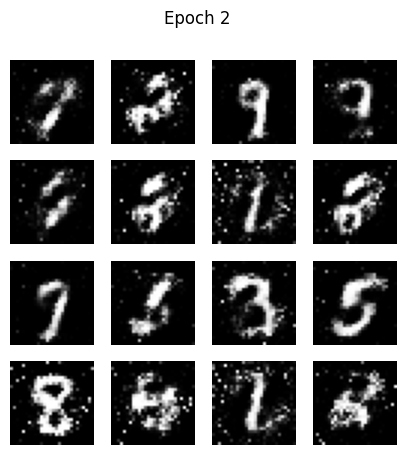


Epoch [3/15]  D_loss: 0.9227  G_loss: 1.1524


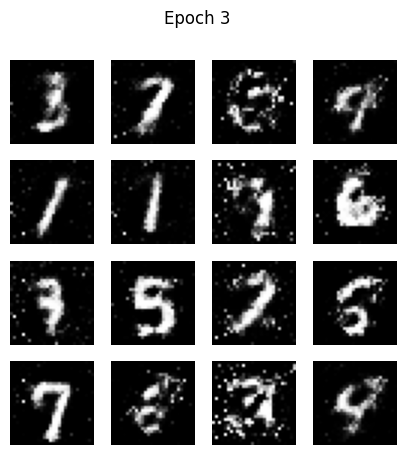


Epoch [4/15]  D_loss: 1.1909  G_loss: 1.0860


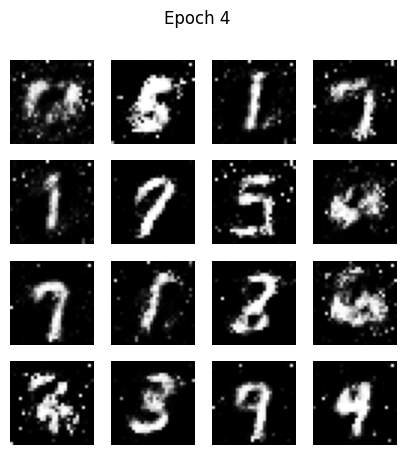


Epoch [5/15]  D_loss: 1.0740  G_loss: 1.5146


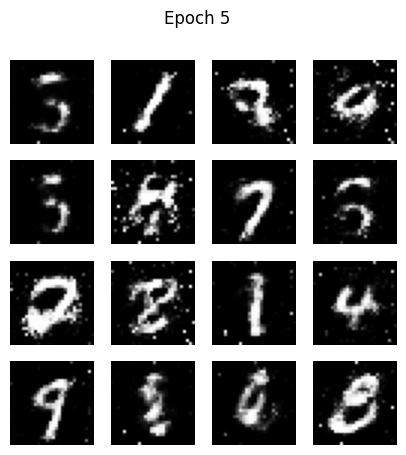


Epoch [6/15]  D_loss: 1.1557  G_loss: 1.2459


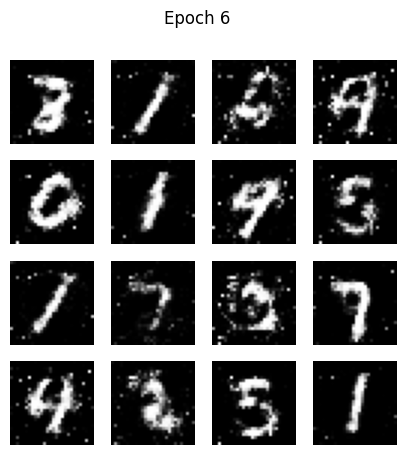


Epoch [7/15]  D_loss: 1.2054  G_loss: 0.9362


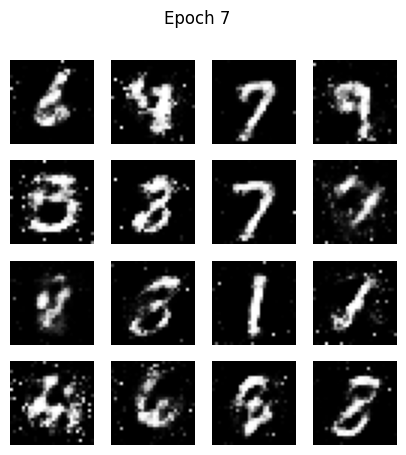


Epoch [8/15]  D_loss: 1.2122  G_loss: 0.7773


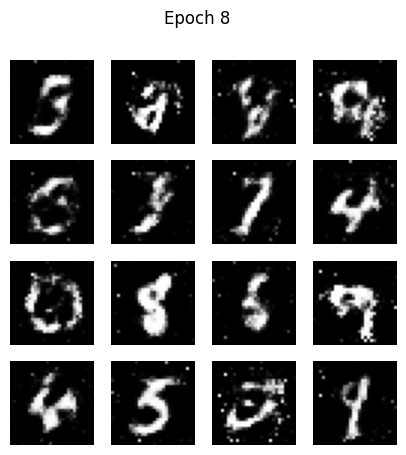


Epoch [9/15]  D_loss: 1.2359  G_loss: 1.1843


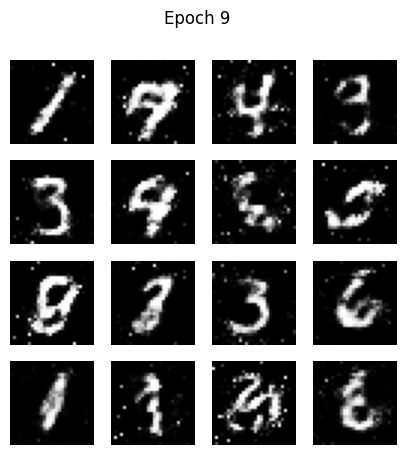


Epoch [10/15]  D_loss: 1.1465  G_loss: 1.3661


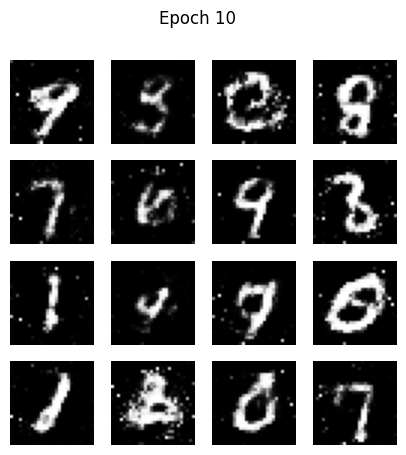


Epoch [11/15]  D_loss: 1.2434  G_loss: 1.3626


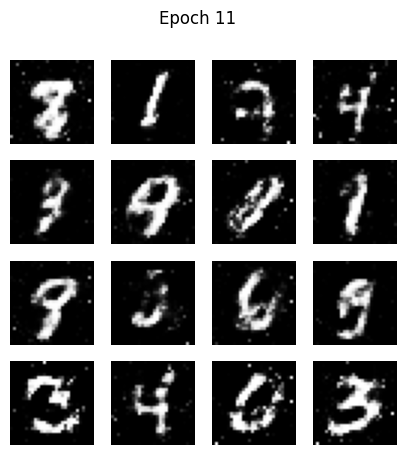


Epoch [12/15]  D_loss: 1.0258  G_loss: 1.5123


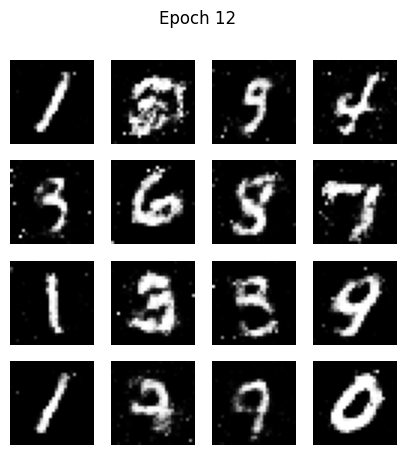


Epoch [13/15]  D_loss: 1.3470  G_loss: 0.5589


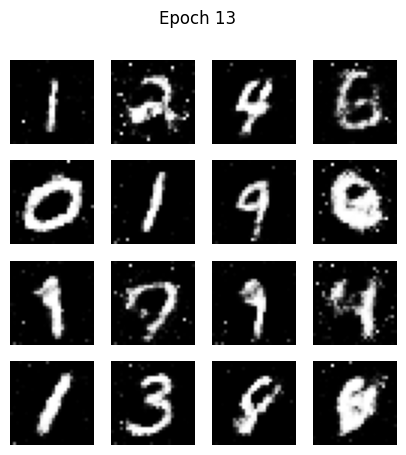


Epoch [14/15]  D_loss: 1.3773  G_loss: 0.6524


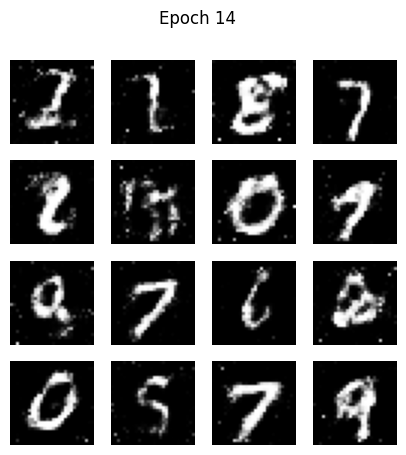


Epoch [15/15]  D_loss: 1.1414  G_loss: 1.4263


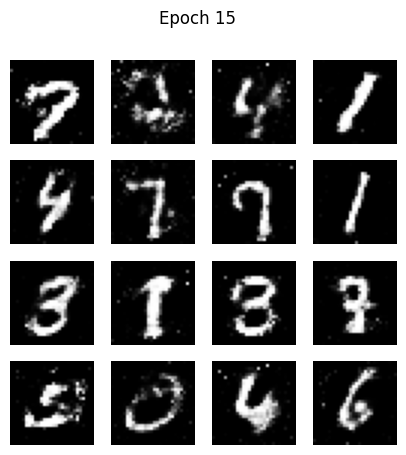

In [ ]:
for epoch in range(epochs):
    for i, (real_imgs, _) in enumerate(dataloader):

        real_imgs = real_imgs.view(real_imgs.size(0), -1).to(device)

        real_labels = torch.full((real_imgs.size(0), 1), 0.9).to(device)
        fake_labels = torch.zeros(real_imgs.size(0), 1).to(device)
        optimizer_D.zero_grad()

        outputs = D(real_imgs)
        d_loss_real = criterion(outputs, real_labels)

        # Generate fake images with noise matching the current batch size
        z = torch.randn(real_imgs.size(0), latent_dim).to(device)
        fake_imgs = G(z)

        outputs = D(fake_imgs.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()


        optimizer_G.zero_grad()

        # Generate fake images again for the generator's step (new z for this step)
        z = torch.randn(real_imgs.size(0), latent_dim).to(device)
        fake_imgs = G(z)

        outputs = D(fake_imgs)
        g_loss = criterion(outputs, real_labels)

        g_loss.backward()
        optimizer_G.step()

    print(f"\nEpoch [{epoch+1}/{epochs}]  D_loss: {d_loss.item():.4f}  G_loss: {g_loss.item():.4f}")


    z = torch.randn(16, latent_dim).to(device)
    generated_imgs = G(z).view(-1, 1, 28, 28).detach().cpu()

    fig, axes = plt.subplots(4, 4, figsize=(5,5))
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated_imgs[i][0], cmap='gray')
        ax.axis('off')

    plt.suptitle(f"Epoch {epoch+1}")
    plt.show()